# N-02 — Como eu codifico meu problema usando Qubits?

- **Trilha:** Núcleo da QC
- **Milestone:** 2 — Codificação
- **Pré-requisito:** [N-01](N-01.ipynb) — O que uma operação unitária faz ao estado?
- **Matemática:** [M-00](../matematica/M-00.ipynb) — Espaço de Hilbert · [M-05](../matematica/M-05.ipynb) — Álgebra Linear
- **Papers:**
  - Shor, P. W. (1994/1996). *Polynomial-Time Algorithms for Prime Factorization and Discrete Logarithms on a Quantum Computer.* [arXiv:quant-ph/9508027](https://arxiv.org/abs/quant-ph/9508027)
  - Yan, B. et al. (2022). *Factoring integers with sublinear resources on a superconducting quantum processor.* [arXiv:2212.12372](https://arxiv.org/abs/2212.12372)

<div style="border-left: 2px solid #6b7280; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(107, 114, 128, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #9ca3af;">ETIMOLOGIA </span><br>
  
  <span style="font-size: 0.88em; line-height: 1.65;"><b>Codificar</b> vem do latim <i>codex</i> (“tronco de árvore”, depois “livro”, “conjunto de regras”). A ideia original é a de organizar algo para que possa ser escrito e entendido. <b>Em termos gerais</b>, codificar é escolher uma forma de representar algo usando um conjunto de símbolos.</span><br>

  <span style="font-size: 0.88em; line-height: 1.65;"><b>Registro</b> vem do latim <i>regestum</i>, de <i>regerere</i> (“anotar”, “registrar”). A ideia original é a de guardar algo para poder consultar depois. <b>Em termos gerais</b>, “registro” é o lugar onde a informação fica armazenada enquanto você trabalha com ela.</span><br>

  <span style="font-size: 0.88em; line-height: 1.65;"><b>Base</b> vem do grego <i>básis</i> (“passo”, “apoio”, “fundamento”). A ideia original é a de algo sobre o qual você se apoia. <b>Em termos gerais</b>, “base” é o conjunto de referências que você usa para descrever alguma coisa.</span><br>

  <span style="font-size: 0.88em; line-height: 1.65;"><b>Iteração</b> vem do latim <i>iteratio</i>, de <i>iterare</i> (“repetir”, “fazer de novo”). A ideia original é a de retomar uma ação várias vezes. <b>Em termos gerais</b>, iteração é cada repetição de um processo, em que o resultado de uma etapa pode servir de ponto de partida para a próxima.</span>

  <span style="font-size: 0.88em; line-height: 1.65;"><b>Fatorar</b> vem do latim <i>factor</i> (“aquele que faz”, “agente”, “produtor”), derivado de <i>facere</i> (“fazer”). A ideia original é a de decompor algo em partes que o produzem. <b>Em termos gerais</b>, fatorar é reescrever algo como produto de elementos mais simples que o compõem.</span>

</div>

## Afirmação introdutória

Codificar um problema em qubits é definir o que os `estados-base` do `registrador quântico` representam. Na prática, isso significa escolher uma correspondência entre `configurações do problema` e `cadeias binárias` escritas na base computacional. Um qubit permite representar duas possibilidades; um registrador com $n$ qubits permite representar $2^n$ estados-base. Então, codificar o problema é decidir como variáveis, candidatos ou respostas possíveis serão traduzidos para esses estados.

Ao longo desta seção, vamos ver como um qubit pode representar uma variável simples, como vários qubits juntos passam a representar um espaço maior de possibilidades, e como diferentes escolhas de codificação mudam a forma como a informação do problema é organizada no sistema quântico.

## 1. Um qubit é uma pergunta com duas respostas possíveis

Em N-01, vimos que o estado de um qubit é um vetor no $\mathbb{C}^2$. Isso é o formalismo. Agora a questão é: **o que esse vetor significa para o seu problema?**

Um bit clássico responde uma pergunta binária: sim/não, ligado/desligado, 0/1. Um qubit faz a mesma coisa — mas antes da medição, ele pode estar em superposição das duas respostas. O ato de codificar é também uma **escolha**, você determina o qubit para representar algo do seu problema.

### 1.1 A base computacional como alfabeto

Quando dizemos "base computacional", estamos nos referindo ao conjunto que contém todas as configurações possíveis.
- 1 qubit, esse conjunto é: $|0\rangle$ , $|1\rangle$; Ou seja, $2^1$ configurações possíveis.
- 2 qubits, esse conjunto é: $|00\rangle$ , $|01\rangle$ , $|10\rangle$ , $|11\rangle$; Ou seja, $2^2$ configurações possíveis.
- 3 qubits, esse conjunto é: $|000\rangle$ , $|001\rangle$ , $|010\rangle$ , $|011\rangle$ , $|100\rangle$ , $|101\rangle$ , $|110\rangle$ , $|111\rangle$; Ou seja, $2^3$ configurações possíveis.

Agora, para fixar a intuição, imagine que os 8 estados de 3 qubits representam 8 pessoas diferentes:

$$
|000\rangle, |001\rangle, |010\rangle, |011\rangle, |100\rangle, |101\rangle, |110\rangle, |111\rangle
$$

Cada uma dessas pessoas tem uma combinação diferente de três características binárias. Por exemplo:
- o primeiro bit diz se ela usa chapéu ou não;
- o segundo bit diz se ela usa óculos ou não;
- o terceiro bit diz se ela está com a mão levantada ou não.

Assim, $|010\rangle$ e $|111\rangle$ não são “coisas misteriosas”: são apenas rótulos binários para perfis diferentes.

No computador clássico, se você quiser testar uma regra — por exemplo, “marque quem satisfaz tal combinação de características” — você normalmente precisa verificar pessoa por pessoa. Já no computador quântico, você pode preparar uma superposição de todas as 8 possibilidades e aplicar essa mesma regra de uma só vez sobre todas elas. É como se você dissesse: “todo mundo que satisfaz essa condição, troque o sinal”; ou, em uma imagem mais intuitiva, “quem não satisfaz, abaixe a mão; quem satisfaz, mantenha”. A operação é aplicada a todas as possibilidades simultaneamente, porque o registrador está em superposição.

<div style="border-left: 2px solid #f59e0b; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(245, 158, 11, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #f59e0b;">Mas Observe</span><br>
  <span style="font-size: 0.88em; line-height: 1.65;">Isso ainda não significa que você pode medir e receber a "ficha completa" das 8 pessoas de uma vez. A medição devolve apenas um resultado. Escrutinar e catalogar os diferentes aspectos de cada pessoa não é o resultado que estamos perseguindo aqui, este tipo de unidade de processamento (QPU) não responde a essa pergunta. </span>
</div>

Agora, quero que você tenha em mente duas ideias diferentes, mas ligadas entre si: **como representamos o problema** e **quantas iterações são necessárias para resolvê-lo**. No exemplo das pessoas, com 3 características binárias, existem $2^3 = 8$ perfis. Se, em vez de 3, houver $n$ características, o número total de perfis passa a ser $N = 2^n$. Portanto, $n = \log_2 N$. Isso significa que o número de características cresce linearmente, mas o número de perfis possíveis cresce exponencialmente.

A partir daí, podemos fazer uma pergunta central: **qual ganho cada iteração produz na resolução do problema?** Em uma CPU, a busca normalmente precisa verificar os perfis individualmente. No pior caso, isso significa percorrer todo o espaço de perfis. No exemplo com 8 perfis, isso pode exigir até 8 verificações. Em geral, quando a busca é feita uma a uma, o custo cresce na ordem de $O(N)$ — isto é, o número de iterações cresce proporcionalmente ao número total de perfis.

Já no QPU, os $N$ perfis podem ser colocados em superposição e usando interferência, conseguimos reforçar os perfis desejados e enfraquecer os demais. Você sai do paradigma 'perguntar individualmente' e entra no 'perguntar simultaneamente a todos'. Em problemas de busca, isso leva a um custo da ordem de $O(\sqrt{N})$, isto é, ele ainda cresce com o tamanho do problema, mas em uma proporção bem menor que no caso clássico. 

Esse é o contraste central: o espaço de possibilidades cresce exponencialmente, mas o modo como CPU e QPU exploram esse espaço é diferente, o segundo explora mais rápido. Mais adiante vamos entender como exatamente conseguimos chegar em $O(\sqrt{N})$ e o que é o ator de 'explorar' as soluções.

### 1.2 O problema que mudou a área: fatorar um número

O número 42 pode ser escrito como $2 \times 3 \times 7$. A isso chamamos de fatorar um número: encontrar quais números, quando multiplicados, produzem exatamente aquele valor. Para um CPU:

- Multiplicar dois primos é trivial: $37 \times 53 = 1961$. 
- Fatorar o produto — dado $1961$, encontrar $37$ e $53$ — é difícil. 

Tão difícil que toda a criptografia de chave pública moderna (RSA) aposta nisso: **qualquer pessoa pode gerar o produto, mas ninguém consegue desfazer a multiplicação em tempo razoável**. O melhor algoritmo clássico conhecido, o *number field sieve*, leva um tempo que é dado por essa fórmula:

$$\exp\!\Big(c\,(\log N)^{1/3}(\log\log N)^{2/3}\Big)$$

Para RSA-2048, o expoente fica em $\sim 110$, e $e^{110}$ é astronômico — intratável. Mas, em 1994, *Peter Shor* mostrou que um computador quântico pode resolver esse mesmo problema em **tempo polinomial**, isto é, um tempo dado por essa fórmula:

$$O((\log N)^2 \log\log N \cdot \log\log\log N)$$

O ponto central: todos os termos são **polinômios e logaritmos** de $\log N$. Nada é exponencial. Para RSA-2048, $(\log N)^2 \approx 2048^2 \approx 4 \times 10^6$ — um número que um computador processa sem dificuldade.

<a href="../digressoes/D-02.ipynb" style="font-size: 0.82em; color: #6b7280; text-decoration: none; border-bottom: 1px dashed #6b7280; white-space: nowrap;">↳ leia mais sobre RSA e essas fórmulas aqui.</a>

Esse resultado sacudiu a área inteira. Não porque alguém quisesse quebrar RSA amanhã, mas porque demonstrou que a forma como você codifica informação em qubits pode transformar um problema intratável em um problema eficiente.

A pergunta que nos interessa aqui é: **como Shor codificou o problema de fatoração usando qubits?**

### 1.3 O que Shor percebeu: fatorar é achar um período

<div style="border-left: 2px solid #16a34a; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(22, 163, 74, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #16a34a;">nota</span><br>
  <span style="font-size: 0.88em; line-height: 1.65;">As vezes você vai ler algo e perceber que não entendeu nada, vai sentir que está descontextualizado. <b>Não se deixe levar por esse sentimento</b>. Mais a frente você entenderá porque estava lendo aquilo.</span>
</div>

<div style="border-left: 2px solid #f59e0b; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(245, 158, 11, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #f59e0b;">atenção</span><br>
  <span style="font-size: 0.88em; line-height: 1.65;">O que eu farei agora é justamente mostrar como um problema prático, a fatoração de números primos, foi codificado em um computador quântico. Estou realmente respondendo a pergunta deste notebook agora.</span>
</div>

Fatorar $N$ significa descobrir quais números o dividem exatamente; a sacada de *Shor* foi não atacar isso de frente, mas reformular o problema como a busca de um **período escondido**. A observação central é de teoria dos números: dado um inteiro $N$ que queremos fatorar, escolhemos um número $x$ que não tenha divisor comum com $N$ além de $1$ — isto é, $\gcd(x,N)=1$. Em seguida, começamos a calcular as potências de $x$:

$$
x^0,\; x^1,\; x^2,\; x^3,\; \dots
$$

mas, a cada passo, não guardamos o número inteiro; guardamos apenas o **resto da divisão por $N$**. Isso é o que significa “reduzir módulo $N$”. Abaixo vou mostrar isso de forma concreta em um exemplo pequeno. A ideia não é ainda explicar todos os detalhes do algoritmo, mas tornar visível a estrutura que Shor explora: em vez de procurar diretamente os fatores de um número composto \(N\), ele observa a periodicidade da função

$$
f(a)=x^a \bmod N.
$$

<div style="border-left: 2px solid #16a34a; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(22, 163, 74, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #16a34a;">nota</span><br>
  <span style="font-size: 0.88em; line-height: 1.65;">
    <b>mod</b> vem do latim <i>modulus</i>, que significa "pequena medida". Essa palavra foi introduzida por Gauss em 1801, na obra <i>Disquisitiones Arithmeticae</i>. A escrita <b>a mod N</b> significa o resto da divisão de <b>a</b> por <b>N</b>. Já a notação <b>a ≡ b (mod N)</b> significa que <b>a</b> e <b>b</b> deixam o mesmo resto quando são divididos por <b>N</b>. De forma equivalente, isso quer dizer que <b>N</b> divide <b>a - b</b>.
  </span>
</div>


 a    x^a  x^a mod N
--------------------
 0      1          1
 1      2          2
 2      4          4
 3      8          8
 4     16          1
 5     32          2
 6     64          4
 7    128          8
 8    256          1
 9    512          2
10   1024          4
11   2048          8

N = 15, x = 2, periodo r = 4
x^(r/2) - 1 = 3
x^(r/2) + 1 = 5
gcd(x^(r/2) - 1, N) = 3
gcd(x^(r/2) + 1, N) = 5


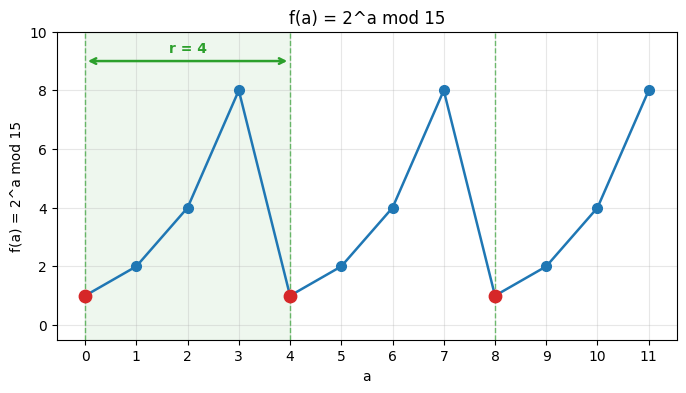

In [1]:
from codigo.nucleo import mostrar_periodicidade_shor

_ = mostrar_periodicidade_shor(N=15, x=2, limite_a=12)

A tabela tem três colunas. A primeira, $a$, é apenas o expoente que estamos testando. A segunda, $x^a$, mostra a potência “normal” de $x$ — por exemplo, com $x=2$, temos $2^0=1$, $2^1=2$, $2^2=4$, $2^3=8$, $2^4=16$ e assim por diante. A terceira coluna, $x^a \bmod N$, mostra apenas o **resto** da divisão dessa potência por $N$. Como aqui $N=15$, quando chegamos em $2^4=16$, o resto por $15$ é $1$. Depois disso, os restos voltam a repetir o mesmo padrão: $1,2,4,8,\dots$

O gráfico não mostra diretamente os fatores de $15$; ele mostra outra coisa: o **período** da função $2^a \bmod 15$. No exemplo, esse período é $r=4$, porque os restos voltam a se repetir a cada $4$ passos. 

Isso é útil porque, quando $r$ é par, $x^r - 1$ pode ser escrito como uma diferença de quadrados:

$$x^r - 1 = (x^{r/2})^2 - 1 = (x^{r/2} - 1)(x^{r/2} + 1)$$

Aqui, como $r = 4$, temos $x^{r/2} = 2^2 = 4$, e portanto:

$$2^4 - 1 = (4 - 1)(4 + 1) = 3 \times 5 = 15$$

Por que isso funciona? Porque pela definição de período $x^r \equiv 1 \pmod{N}$ — significa: quando você divide $x$ por $N$, o resto é 1 — , logo $x^r - 1 \equiv 0 \pmod{N}$, o que se fatora como:

$$
(x^{r/2} - 1)(x^{r/2} + 1) \equiv 0 \pmod{N}
$$

Isso significa que $N$ divide o produto desses dois números. Se $N$ não dividir 
nenhum deles sozinho, então $\gcd(x^{r/2} - 1,\, N)$ e $\gcd(x^{r/2} + 1,\, N)$ 
são fatores não-triviais de $N$.

### 1.4 O que é um registro quântico

Um registro quântico é um grupo de qubits que, juntos, representam um `número em binário`. No nosso caso, precisamos de 4 qubits, então são 4 dispositivos — não interessa o que são esses dispositivos aqui, estamos focados na abstração qubit — e fazer deles um grupo.

Com 3 qubits, você tem um registro que pode estar em qualquer um dos $2^3 = 8$ estados da base computacional: $|000\rangle, |001\rangle, |010\rangle, \dots, |111\rangle$. Cada um desses estados representa um inteiro — $0, 1, 2, \dots, 7$. O estado $|101\rangle$ significa $a = 5$, porque $1 \cdot 2^2 + 0 \cdot 2^1 + 1 \cdot 2^0 = 5$. Então, até aqui não há nada de muito 'diferente' para um computador clássico. Vou dizer a diferença agora:

<div style="border-left: 3px solid #2563eb; padding: 0.6em 1em 0.6em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(37, 99, 235, 0.08); border-radius: 0 4px 4px 0;">
  <span style="font-size: 0.65em; font-weight: 800; letter-spacing: 0.14em; text-transform: uppercase; color: #2563eb;">lembrando</span><br> 
  <span style="font-size: 0.9em; line-height: 1.65;">
    Uma <b>porta quântica</b> é uma transformação elementar e unitária feita no circuito. Existem diversos tipos delas. Até aqui, não entrei em detalhes sobre elas, só mostrei que elas existem e que são transformações unitárias.
  </span>
</div>

<div style="border-left: 3px solid #dc2626; padding: 0.6em 1em 0.6em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(220, 38, 38, 0.08); border-radius: 0 4px 4px 0;">
  <span style="font-size: 0.65em; font-weight: 800; letter-spacing: 0.14em; text-transform: uppercase; color: #dc2626;">ponto fulcral</span><br>
  <span style="font-size: 0.9em; line-height: 1.65;">
    Se você aplicar uma <b>porta Hadamard</b> em cada um dos 3 qubits, o registro inteiro entra em <b>superposição uniforme</b> de todos os 8 valores ao mesmo tempo. São 3 qubits físicos, mas o espaço que eles acessam tem 8 dimensões.
  </span>
</div>

Para representar valores de 0 até $N-1$, você precisa de $\lceil \log_2 N \rceil$ qubits. Se $N = 15$, precisa de 4 qubits (porque $2^3 = 8 < 15$, mas $2^4 = 16 \geq 15$).

### 1.5 Como *Shor* organiza os registros

No exemplo com $N = 15$, bastou calcular 4 valores de $2^a \bmod 15$ para encontrar o período. Mas o período $r$ pode ser tão grande quanto $N$ — e para $N$ com milhares de dígitos, percorrer a sequência um a um é intratável. Mas *Shor* sabia que seria possível colocar **todos** os valores de $a$ em superposição de uma só vez e extrair $r$ por interferência.

Shor usa **dois grupos de qubits** — dois registradores — porque ele precisa guardar **duas coisas ao mesmo tempo**: a entrada que está sendo testada e o valor da função nessa entrada. O **primeiro registrador** serve para representar os possíveis valores de $a$; ele é colocado em superposição para que muitos valores de $a$ existam ao mesmo tempo no estado quântico. O **segundo registrador** serve para armazenar o resultado de $x^a \bmod N$ para cada um desses valores.

<div style="border-left: 2px solid #16a34a; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(22, 163, 74, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #16a34a;">nota</span><br>
  <span style="font-size: 0.88em; line-height: 1.65;">
    Tenha em mente que <b>a</b> é o número que diz qual potência de <b>x</b> estamos calculando em <b>x<sup>a</sup></b>.<br>
    Só depois disso aplicamos <b>mod N</b>, isto é, olhamos apenas para o resto da divisão desse valor por <b>N</b>.
  </span>
</div>

A ideia de fazer isso em dois registradores é preservar a correspondência entre “entrada” e “saída”: para cada $a$, o sistema passa a carregar também o valor correspondente de $x^a \bmod N$. É nessa tabela quântica de pares $(a, x^a \bmod N)$ que o período fica codificado. Depois, a transformada de Fourier quântica atua sobre essa estrutura para tornar o período observável por interferência.

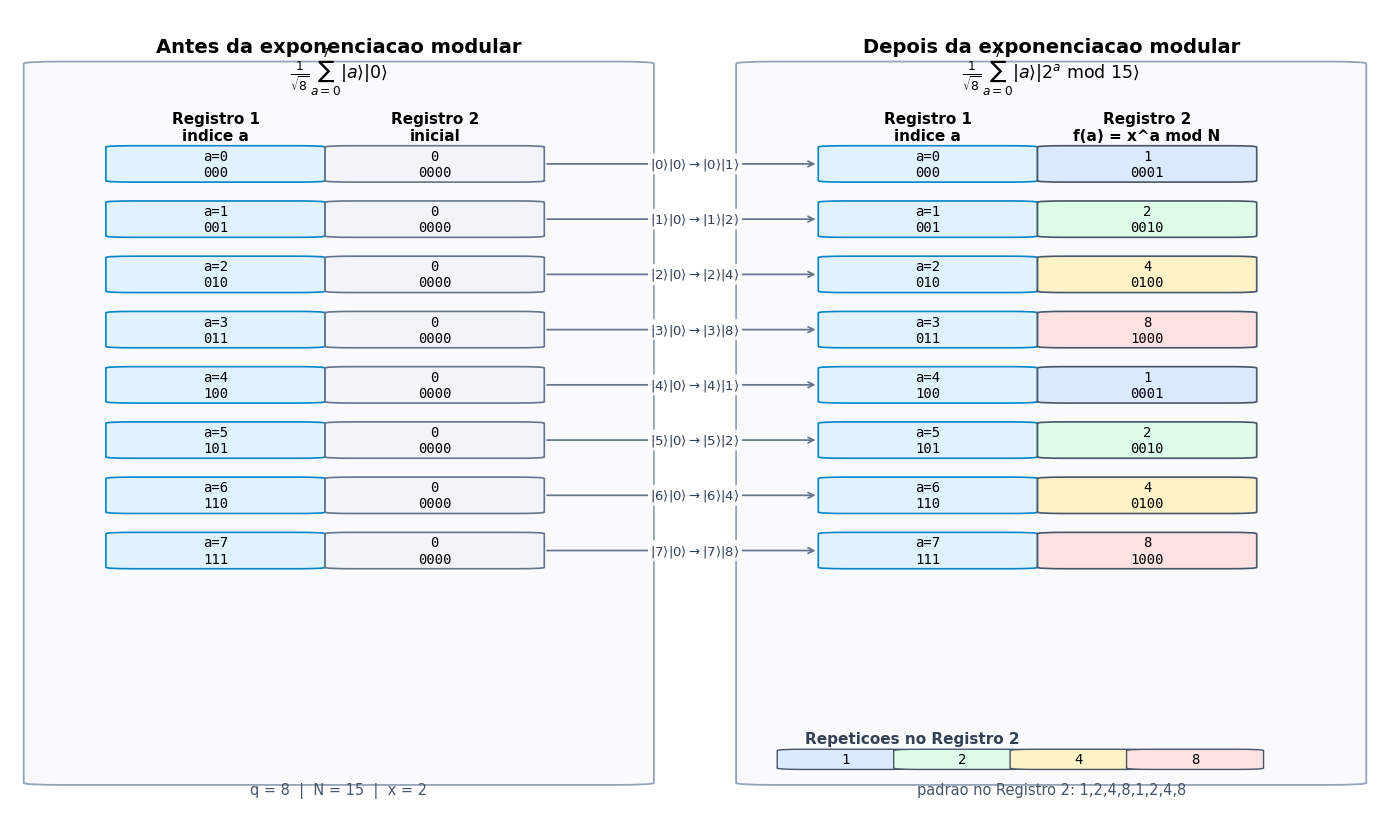

In [3]:
from codigo.nucleo import mostrar_registradores_shor

_ = mostrar_registradores_shor(N=15, x=2, q=8)

**Registro 1** (entrada): é o registrador que vai guardar os valores de $a$ que queremos testar na função $f(a) = x^a \bmod N$. Ele contém $ t = \lceil 2\log_2 N \rceil $ qubits. Mais adiante vou explicar por que escolhemos aproximadamente $ 2\log_2 N $ qubits; por enquanto, basta notar o seguinte: com $t$ qubits, conseguimos representar $ q = 2^t $ valores inteiros diferentes na base computacional. Ou seja, esse registrador pode representar todos os inteiros de $ 0 \text{ até } q-1. $

Cada estado da base computacional $|a\rangle$ corresponde, portanto, a um desses inteiros. Por exemplo, se tivermos 3 qubits, então há $2^3 = 8$ estados possíveis, e eles representam os valores de $a=0$ até $a=7$. No algoritmo, esse primeiro registrador não é preparado com um único valor de $a$, mas sim em uma **superposição uniforme** de todos os valores que ele pode representar. Isso significa que, antes do cálculo da função, ele fica no estado: 

$$ 
\frac{1}{\sqrt{q}} \sum_{a=0}^{q-1} |a\rangle |0\rangle 
$$

Aqui:
- $|a\rangle$ representa o valor armazenado no **Registro 1**;
- $|0\rangle$ representa o **Registro 2**, inicialmente zerado;
- o fator $\frac{1}{\sqrt{q}}$ serve para normalizar a superposição.

Em outras palavras: o primeiro registrador é preparado como se contivesse **todos os valores de $a$ ao mesmo tempo**, enquanto o segundo começa vazio, pronto para receber o resultado de $f(a) = x^a \bmod N$.

**Registro 2** (saída): recebe o resultado de $x^a \bmod N$. Por enquanto, não vou entrar em como esse cálculo é implementado dentro do circuito quântico; nesta etapa, o importante é apenas entender o que essa operação faz do ponto de vista da codificação dos estados. Depois dessa operação, o estado do sistema é:


$$\frac{1}{\sqrt{q}} \sum_{a=0}^{q-1} |a\rangle \,|x^a \bmod N\rangle$$

Em outras palavras: o primeiro registrador é preparado como se contivesse todos os valores de $a$ ao mesmo tempo, enquanto o segundo começa vazio, pronto para receber o resultado de $f(a) = x^a \bmod N$.  

### 1.6 Como a exponenciação modular é calculada

Agora sim, vou explicar o circuito que calcula $x^a \bmod N$. Ele não faz nada misterioso: implementa uma versão reversível da exponenciação modular clássica. Considere:

$$
a = a_0 + 2a_1 + 4a_2 + 8a_3 + \cdots
$$

onde cada $a_i$ é um bit, isto é, pode valer apenas $0$ ou $1$. Agora pense com calma no que essa expressão está dizendo. Ela apenas escreve o número $a$ em binário. Cada bit $a_i$ responde à pergunta: a potência $2^i$ entra ou não entra na composição de $a$?

Se o bit vale $0$, aquela parcela não contribui. Se o bit vale $1$, aquela parcela contribui. Por isso, escrever

$$
a = a_0 + 2a_1 + 4a_2 + 8a_3 + \cdots
$$

é apenas outra forma de dizer que $a$ é formado pela soma das potências de $2$ cujos bits estão ligados.

Por exemplo, se $a = 13$, então sua escrita em binário é $13 = 1101_2$.

Isso significa:

$$
13 = 1\cdot 2^0 + 0\cdot 2^1 + 1\cdot 2^2 + 1\cdot 2^3
= 1 + 0 + 4 + 8
$$

Ou seja: os bits ligados de $13$ indicam que ele é composto por $1$, $4$ e $8$.

Agora vem a ideia central. Se

$$
a = a_0 + 2a_1 + 4a_2 + 8a_3 + \cdots,
$$

então

$$
x^a = x^{a_0 + 2a_1 + 4a_2 + 8a_3 + \cdots}
$$

E aqui usamos uma propriedade básica de potências:

$$
x^{u+v+w+\cdots} = x^u \cdot x^v \cdot x^w \cdots
$$

Portanto,

$$
x^a = x^{a_0} \cdot x^{2a_1} \cdot x^{4a_2} \cdot x^{8a_3} \cdots
$$

Até aqui não há nada quântico. É apenas álgebra comum.

A vantagem dessa forma é que cada expoente depende de um único bit. Como cada $a_i$ só pode ser $0$ ou $1$, cada fator fica muito simples:

$$
x^{2^i a_i}
=
\begin{cases}
1, & \text{se } a_i = 0 \\
x^{2^i}, & \text{se } a_i = 1
\end{cases}
$$

Isto é: para cada bit de $a$, ou aquele fator não entra, ou entra uma potência fixa de $x$.

Voltando ao exemplo $a = 13$, temos:

$$
13 = 1 + 4 + 8
$$

logo,

$$
x^{13} = x^{1+4+8} = x^1 \cdot x^4 \cdot x^8
$$

É exatamente isso que a decomposição binária permite fazer: transformar o cálculo de $x^a$ em uma sequência de decisões controladas pelos bits de $a$.

No algoritmo de Shor, a versão relevante é a modular. Então, em vez de calcular apenas $x^a$, calculamos $x^a \bmod N$.

A ideia é a mesma:

$$
x^a \bmod N
=
\left(
x^{a_0} \cdot x^{2a_1} \cdot x^{4a_2} \cdot x^{8a_3} \cdots
\right) \bmod N
$$

Na prática, isso permite montar o circuito de forma organizada: cada bit do registrador que armazena $a$ controla se devemos ou não multiplicar o segundo registrador por uma certa constante pré-calculada, como $x^{2^0} \bmod N$, $x^{2^1} \bmod N$, $x^{2^2} \bmod N$, e assim por diante.

Portanto, o circuito não “descobre magicamente” $x^a \bmod N$. Ele apenas lê os bits de $a$ e, com base neles, compõe o resultado a partir dessas potências previamente conhecidas.

### 1.7 O que essa codificação definiu

A decisão de codificação definiu tudo: quais qubits carregam qual parte do problema, e como a informação será lida no final. Para o Shor original, RSA-2048 exigiria milhões de qubits físicos com correção de erros.

A escolha de codificação de Shor determinou tudo o que vem depois: quais qubits carregam qual parte do problema, como a informação é processada e como ela é lida no final.

Essa escolha tem um custo. O primeiro registro precisa de $O(\log N)$ qubits. O circuito de exponenciação modular tem profundidade $O((\log N)^2)$. E tudo isso precisa funcionar com correção de erros, porque qualquer ruído durante a exponenciação ou a transformada de Fourier corrompe o resultado. Para RSA-2048, a estimativa é de ~20 milhões de qubits físicos.

Esse custo não é inevitável — é consequência **dessa** codificação. Outros mapeamentos do mesmo problema de fatoração levam a custos radicalmente diferentes. É o que veremos na seção 3.

## 2. Generalizando: três formas de codificar

Um problema real raramente cabe em um qubit. Para codificar problemas maiores, você combina qubits — e aqui aparece a estrutura que dá poder à computação quântica.

### 2.1 Compor qubits é fazer o produto tensorial dos espaços

Se um qubit vive em $\mathbb{C}^2$, dois qubits vivem em $\mathbb{C}^2 \otimes \mathbb{C}^2 = \mathbb{C}^4$. A base computacional agora tem quatro elementos: $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$.

Com $n$ qubits, o espaço é $\mathbb{C}^{2^n}$. A base computacional tem $2^n$ vetores. Cada vetor da base é uma string binária de $n$ bits — e essa string é a "palavra" que codifica uma configuração do seu problema.

### 2.2 Cada vetor da base é uma configuração possível

Suponha que seu problema tem 3 variáveis binárias: $x_1, x_2, x_3$. Você aloca 3 qubits. O estado $|101\rangle$ significa $x_1 = 1, x_2 = 0, x_3 = 1$.

A superposição $\frac{1}{\sqrt{8}}\sum_{x \in \{0,1\}^3} |x\rangle$ representa **todas as 8 configurações ao mesmo tempo**, cada uma com amplitude igual. Preparar essa superposição uniforme é o ponto de partida de vários algoritmos — Deutsch-Jozsa, Grover, Simon.

### 2.3 Emaranhamento: correlação que não existe classicamente

Nem todo estado de múltiplos qubits pode ser escrito como produto tensorial de estados individuais. Quando isso acontece, dizemos que os qubits estão **emaranhados**.

O estado $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ não pode ser fatorado em $|\psi_1\rangle \otimes |\psi_2\rangle$ — os dois qubits estão correlacionados de uma forma que não tem análogo clássico. Para a codificação, isso importa: emaranhamento permite representar **restrições entre variáveis** diretamente no estado, sem precisar de bits extras para armazenar a correlação.

## 3. Custos e trade-offs

A escolha de como mapear o problema para qubits não é única. Existem diferentes estratégias de codificação, cada uma com trade-offs de custo (número de qubits, profundidade do circuito) e expressividade.

### 3.1 Codificação na base computacional

A mais direta: cada configuração do problema é um vetor da base. Se o problema tem $n$ variáveis binárias, você usa $n$ qubits e cada string $|x_1 x_2 \dots x_n\rangle$ representa uma atribuição de valores.

É a codificação usada em Grover e em problemas de otimização combinatória (QAOA). Vantagem: a leitura é direta — você mede e obtém a resposta como uma string de bits. Custo: o número de qubits escala linearmente com o número de variáveis.

### 3.2 Codificação nas amplitudes

Em vez de usar a **posição** na base computacional, você codifica a informação nos **valores** das amplitudes. Um vetor com $2^n$ amplitudes pode representar $2^n$ números reais com apenas $n$ qubits.

É a codificação usada em HHL (sistemas lineares) e em alguns algoritmos de machine learning quântico. Vantagem: compressão exponencial — $2^n$ dados em $n$ qubits. Custo: preparar o estado (carregar as amplitudes) e extrair a informação (tomografia) pode ser caro.

### 3.3 Codificação no Hamiltoniano

Aqui, o problema é codificado não no estado inicial, mas na **operação** que age sobre os qubits. Você constrói um operador $H$ (o Hamiltoniano) cujo estado de menor energia corresponde à solução do problema.

É a codificação usada em computação quântica adiabática e em VQE (Variational Quantum Eigensolver). O sistema quântico evolui sob $H$ e, se tudo correr bem, "relaxa" para o estado que codifica a resposta. Vantagem: natural para problemas de otimização e simulação de física. Custo: mapear o problema para um Hamiltoniano que seja implementável no hardware disponível.

## 4. Do mapeamento à construção do circuito

Escolhida a codificação, o próximo passo é construir o circuito que:

1. **Prepara** o estado inicial (colocar o problema no registro),
2. **Transforma** o estado (aplicar as operações que processam a informação),
3. **Mede** o estado final (extrair a resposta).

Esse fluxo — preparação → transformação → medição — é o modelo de circuito quântico, e é o ponto onde a codificação encontra a computação. Cada escolha de codificação implica circuitos de preparação diferentes e custos diferentes para leitura.

### 4.1 O oráculo: codificar a resposta como transformação

Em muitos algoritmos, o problema aparece como um **oráculo** — uma operação unitária $U_f$ que implementa a função $f$ do problema. Para a entrada $|x\rangle$, o oráculo marca ou modifica o estado de acordo com $f(x)$.

Isso é central em Deutsch-Jozsa, Bernstein-Vazirani e Grover: você não codifica as respostas no estado inicial, mas no **efeito** que o oráculo tem sobre a superposição. A codificação do problema, nesse caso, está na construção de $U_f$.

### 4.2 Custo real: qubits, profundidade e leitura

Toda codificação tem três custos que competem entre si:

- **Qubits necessários** — quantos qubits o mapeamento exige.
- **Profundidade do circuito** — quantas operações sequenciais são necessárias para preparar o estado ou aplicar o oráculo.
- **Custo de leitura** — quanta informação você consegue extrair por medição, e quantas medições são necessárias.

Codificação em amplitudes, por exemplo, usa poucos qubits mas pode exigir circuitos profundos para carregar os dados e muitas medições para ler o resultado. Codificação na base computacional usa mais qubits mas a leitura é direta. Não existe codificação universalmente melhor — existe a mais adequada ao problema e ao hardware.

## 5. O que este notebook respondeu

- Codificar é escolher qual pergunta cada qubit responde — é mapear variáveis do problema para estados da base computacional.
- A base computacional $\{|0\rangle, |1\rangle\}^{\otimes n}$ é o alfabeto padrão; cada string binária é uma configuração do problema.
- O espaço de estados cresce como $2^n$ — o produto tensorial compõe qubits e cria o espaço onde o algoritmo trabalha.
- Existem formas distintas de codificação (na base, nas amplitudes, no Hamiltoniano), cada uma com trade-offs de custo.
- O oráculo é uma forma de codificar o problema como transformação, não como estado.

## 6. O que este notebook não respondeu

- Como construir concretamente o oráculo $U_f$ para um problema específico — isso envolve síntese de circuitos.
- Como preparar eficientemente um estado de amplitudes arbitrárias — o problema do *state preparation* é um campo aberto.
- Como lidar com erros na codificação — isso é o domínio da correção de erros quânticos.
- Como escolher a codificação ótima para um dado hardware — isso depende da topologia e das taxas de erro do processador.

# LIXO


<div style="border-left: 3px solid #2563eb; padding: 0.6em 1em 0.6em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(37, 99, 235, 0.08); border-radius: 0 4px 4px 0;">
  <span style="font-size: 0.65em; font-weight: 800; letter-spacing: 0.14em; text-transform: uppercase; color: #2563eb;">lembrando</span><br> 
  <span style="font-size: 0.9em; line-height: 1.65;">
    Uma amplitude complexa é um número do tipo <i>r</i>e<sup>iφ</sup> que acompanha uma possibilidade:<br>
    - <i>r</i> determina o peso dessa possibilidade;<br>
    - Se você fizer <i>r</i><sup>2</sup> terá a probabilidade associada a ela;<br>
    - φ é sua fase, que determinna como possibilidades direntes se combinam<br>
  </span>
</div>

Você já entendeu que qualquer estado do qubit é uma combinação linear desses dois, com amplitudes complexas que determinam as probabilidades de cada resultado. O que muda em relação ao bit clássico: um bit **é** 0 ou **é** 1; um qubit em superposição $\alpha|0\rangle + \beta|1\rangle$ carrega ambas as possibilidades com amplitudes definidas — até que uma medição force uma resposta.

<div style="border-left: 3px solid #2563eb; padding: 0.6em 1em 0.6em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(37, 99, 235, 0.08); border-radius: 0 4px 4px 0;">
  <span style="font-size: 0.65em; font-weight: 800; letter-spacing: 0.14em; text-transform: uppercase; color: #2563eb;">lembrando</span><br> 
  <span style="font-size: 0.9em; line-height: 1.65;">
    α e 𝛽 são exatamente amplitudes complexas desse tipo, como <i>r</i>e<sup>iφ</sup>
  </span>
</div>